In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('../data/data_encoded.csv')

In [4]:
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'income', 'age_group', 'work_intensity', 'education_rank', 'overtime',
       'sex_encoded', 'income_encoded'],
      dtype='object')

In [23]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,...,capital-loss,hours-per-week,native-country,income,age_group,work_intensity,education_rank,overtime,sex_encoded,income_encoded
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,...,0,40,United-States,<=50K,36-45,Standard (20-40),13.0,0,1,0
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,...,0,13,United-States,<=50K,46-55,Part-time (<20),13.0,0,1,0
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,...,0,40,United-States,<=50K,36-45,Standard (20-40),9.0,0,1,0
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,...,0,40,United-States,<=50K,46-55,Standard (20-40),7.0,0,1,0
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,...,0,40,Other,<=50K,26-35,Standard (20-40),13.0,0,0,0


In [5]:
df.dtypes

age                 int64
workclass          object
fnlwgt              int64
education          object
education-num       int64
marital-status     object
occupation         object
relationship       object
race               object
sex                object
capital-gain        int64
capital-loss        int64
hours-per-week      int64
native-country     object
income             object
age_group          object
work_intensity     object
education_rank    float64
overtime            int64
sex_encoded         int64
income_encoded      int64
dtype: object

In [6]:
df[["education-num", 'sex_encoded', 'income_encoded', 'education_rank', 'overtime']].head()

,education-num,sex_encoded,income_encoded,education_rank,overtime
0,13,1,0,13.0,0
1,13,1,0,13.0,0
2,9,1,0,9.0,0
3,7,1,0,7.0,0
4,13,0,0,13.0,0


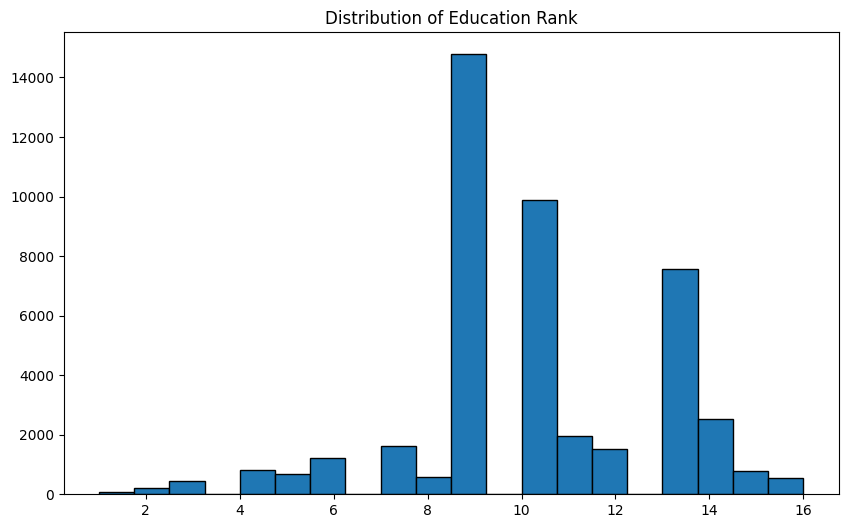

In [7]:
plt.figure(figsize=(10,6))
plt.hist(df['education_rank'], bins=20, edgecolor='k')
plt.title('Distribution of Education Rank') 
plt.show()

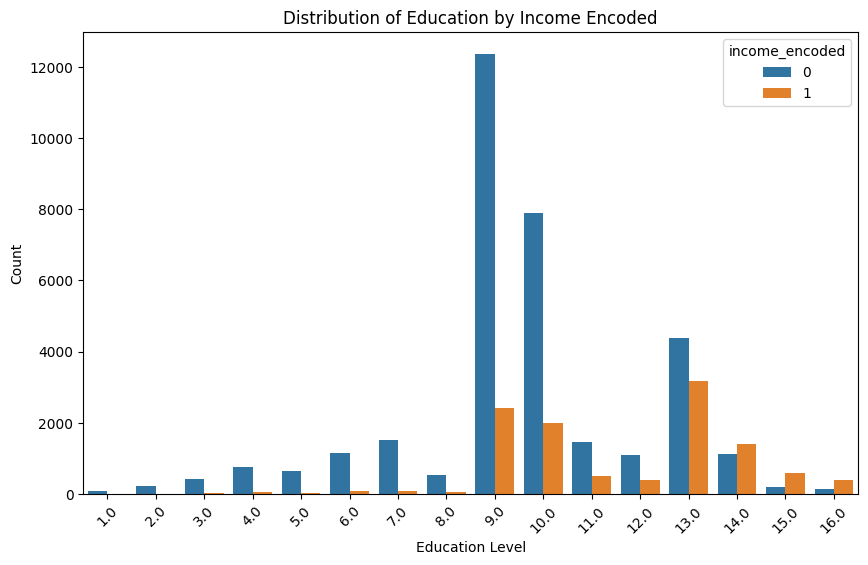

In [8]:
plt.figure(figsize=(10,6))
sns.countplot(x='education_rank', hue='income_encoded', data=df)

plt.title('Distribution of Education by Income Encoded')
plt.xlabel('Education Level')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

education-num: [13  9  7 14  5 10 12  4 16 11 15  3  6  1  8  2]
sex_encoded: [1 0]
income_encoded: [0 1]
education_rank: [13.  9.  7. 14.  5. 10. 12.  4. 16. 11. 15.  3.  6.  1.  8.  2.]
overtime: [0 1]


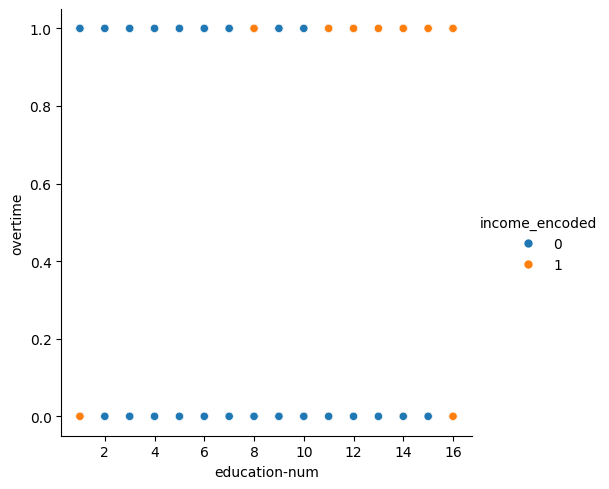

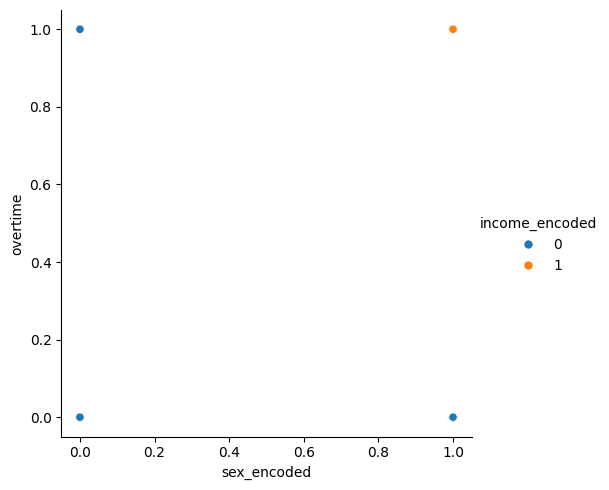

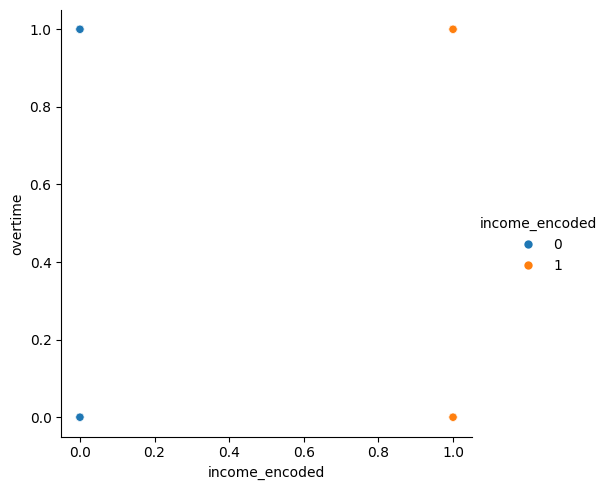

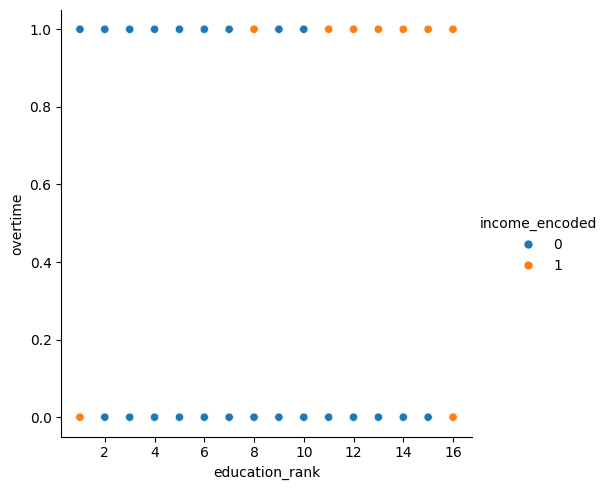

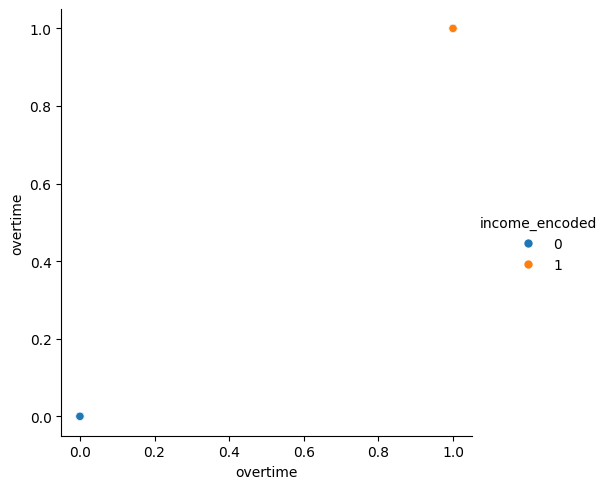

In [9]:
encode_col = ["education-num", 'sex_encoded', 'income_encoded', 'education_rank', 'overtime']
for col in encode_col:
    print(f"{col}: {df[col].unique()}") 
    sns.relplot(x=col, y='overtime', hue='income_encoded', data=df)

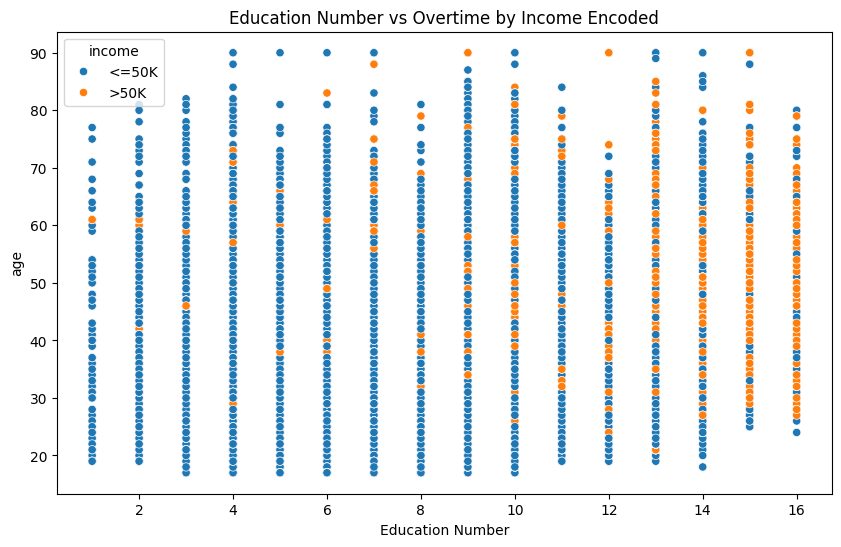

In [31]:
# scatter plot for education-num vs overtime
plt.figure(figsize=(10,6))
sns.scatterplot(x='education-num', y='age', hue='income', data=df)
plt.title('Education Number vs Overtime by Income Encoded')
plt.xlabel('Education Number')
plt.ylabel('age')
plt.show()

                     age    fnlwgt  education-num  capital-gain  capital-loss  \
age             1.000000 -0.075613       0.037430      0.079679      0.059316   
fnlwgt         -0.075613  1.000000      -0.042033     -0.004116     -0.004357   
education-num   0.037430 -0.042033       1.000000      0.126951      0.081709   
capital-gain    0.079679 -0.004116       0.126951      1.000000     -0.032123   
capital-loss    0.059316 -0.004357       0.081709     -0.032123      1.000000   
hours-per-week  0.101735 -0.018680       0.146401      0.083875      0.054159   
education_rank  0.037430 -0.042033       1.000000      0.126951      0.081709   
overtime        0.077580 -0.029608       0.176114      0.083846      0.058486   
sex_encoded     0.081981  0.027351       0.003353      0.047454      0.046464   
income_encoded  0.237012 -0.007300       0.332943      0.221034      0.148658   

                hours-per-week  education_rank  overtime  sex_encoded  \
age                   0.101735     

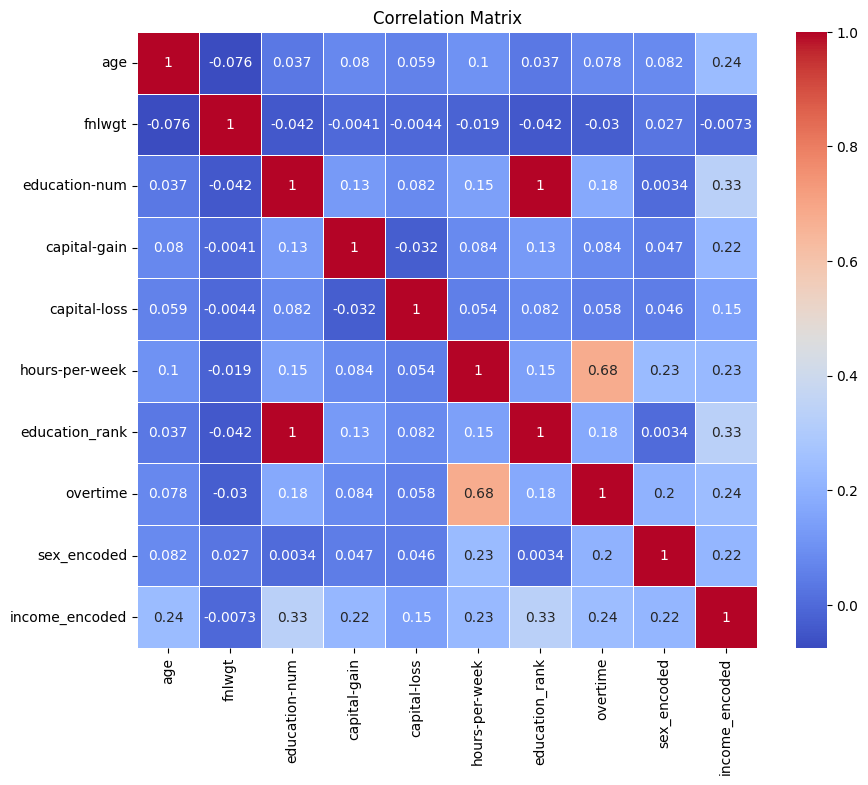

In [22]:
# find correlation between columns
correlation_matrix = df.select_dtypes(include=[np.number]).corr()
print(correlation_matrix)
plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()


# Linear regression

In [28]:
# by linear regression
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
X = df[["education-num", 'sex_encoded', 'education_rank', 'overtime', 'age']]
y = df['income_encoded']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

Mean Squared Error: 0.1451909142375688
R-squared: 0.2259338326537882


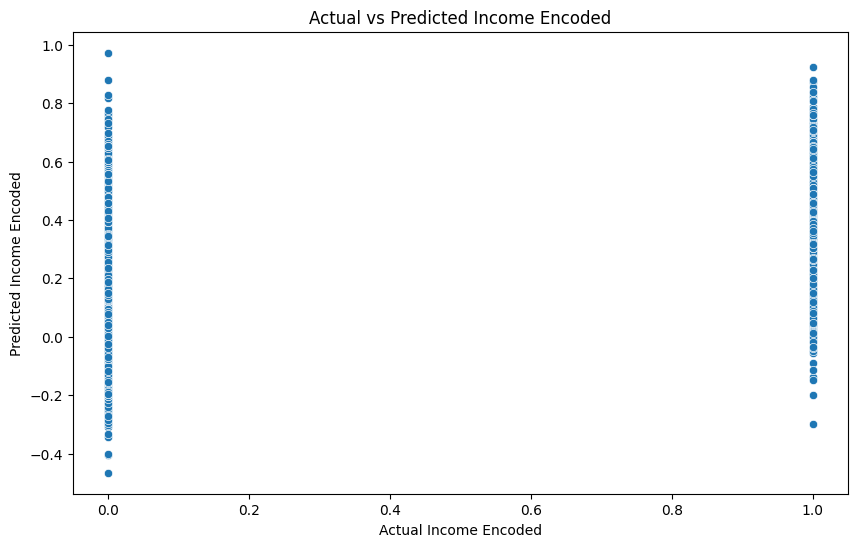

In [ ]:
# scatter plot of actual vs predicted values
plt.figure(figsize=(10,6))
sns.scatterplot(x=y_test, y=y_pred)
plt.title('Actual vs Predicted Income Encoded')
plt.xlabel('Actual Income Encoded')
plt.ylabel('Predicted Income Encoded')
plt.show()

In [39]:
# test model with new data
new_data = pd.DataFrame({
    "education-num": [10],
    'sex_encoded': [1],
    'education_rank': [3],
    'overtime': [0],
    'age': [30]
})
predicted_income = model.predict(new_data)
print(f"Predicted Income Encoded: {predicted_income[0]}")

Predicted Income Encoded: 0.018493545133062672


In [41]:
new_data = pd.DataFrame({
    "education-num": [13],
    'sex_encoded': [1],
    'education_rank': [1],
    'overtime': [1],
    'age': [30]
})
predicted_income = model.predict(new_data)
print(f"Predicted Income Encoded: {predicted_income[0]}")

Predicted Income Encoded: 0.17403816651972093


# Logistic Regression model

In [42]:
# Train logistic regression model
from sklearn.linear_model import LogisticRegression
logistic_model = LogisticRegression()
logistic_model.fit(X_train, y_train)
y_pred_logistic = logistic_model.predict(X_test)
print(f"Logistic Regression Accuracy: {logistic_model.score(X_test, y_test)}")

Logistic Regression Accuracy: 0.796990817568315


In [ ]:
# Test logistic regression model with new data
new_data = pd.DataFrame({
    "education-num": [13],
    'sex_encoded': [1],
    'education_rank': [1],
    'overtime': [1],
    'age': [30]
})
new_prediction = logistic_model.predict(new_data)
print(f"Predicted Income Encoded (Logistic Regression): {new_prediction[0]}")

Predicted Income Encoded (Logistic Regression): 0


# Decition Tree

In [46]:
# Train a Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier
tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)
from sklearn.metrics import accuracy_score
accuracy_tree = accuracy_score(y_test, y_pred_tree)
print(f"Decision Tree Accuracy: {accuracy_tree}")

Decision Tree Accuracy: 0.7913486005089059


In [48]:
# Train a Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)
print(f"Random Forest Mean Squared Error: {mse_rf}")
print(f"Random Forest R-squared: {r2_rf}")

Random Forest Mean Squared Error: 0.14385487965973798
Random Forest R-squared: 0.2330567244031394


In [49]:
#Gradient Boosting Regressor
from sklearn.ensemble import GradientBoostingRegressor
gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)
mse_gb = mean_squared_error(y_test, y_pred_gb)
r2_gb = r2_score(y_test, y_pred_gb)
print(f"Gradient Boosting Mean Squared Error: {mse_gb}")
print(f"Gradient Boosting R-squared: {r2_gb}")

Gradient Boosting Mean Squared Error: 0.1347084852975434
Gradient Boosting R-squared: 0.28181951693846596


# Rectified Linear Unit

In [47]:
# Train  Rectified Linear Unit
from sklearn.neural_network import MLPClassifier
relu_model = MLPClassifier(hidden_layer_sizes=(100,), activation='relu', max_iter=300, random_state=42)
relu_model.fit(X_train, y_train)
y_pred_relu = relu_model.predict(X_test)
accuracy_relu = accuracy_score(y_test, y_pred_relu)
print(f"ReLU Neural Network Accuracy: {accuracy_relu}")

ReLU Neural Network Accuracy: 0.8036287199911495


# Perform Train test


In [ ]:
# Split data into training and testing sets
results = {
    'Model': ['Linear Regression', 'Logistic Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting', 'ReLU Neural Network'],
    'Accuracy/MSE': [r2, logistic_model.score(X_test, y_test), accuracy_tree, mse_rf, mse_gb, accuracy_relu]
}
results_df = pd.DataFrame(results)
print(results_df)

                 Model  Accuracy/MSE
0    Linear Regression      0.225934
1  Logistic Regression      0.796991
2        Decision Tree      0.791349
3        Random Forest      0.143855
4    Gradient Boosting      0.134708
5  ReLU Neural Network      0.803629


## Cross-Validation

In [53]:
# Cross-validation
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(logistic_model, X, y, cv=5)
print(f"Cross-validation scores: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean()}")

Cross-validation scores: [0.7962164  0.79876092 0.80174798 0.7937825  0.78855942]
Mean CV Accuracy: 0.7958134430670605


# Key finding

# Model Validation

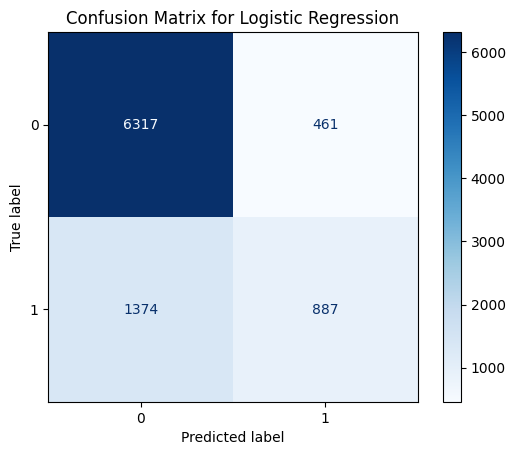

In [55]:
# confusion matrix for logistic regression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred_logistic)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=logistic_model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Logistic Regression')
plt.show()

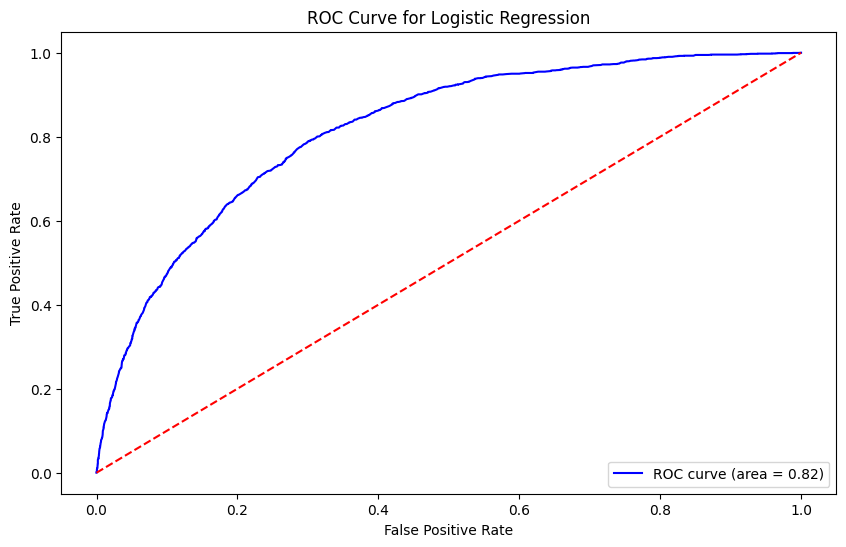

In [56]:
# ROC curve for logistic regression
from sklearn.metrics import roc_curve, auc
y_prob_logistic = logistic_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob_logistic)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(10,6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle ='--')
plt.title('ROC Curve for Logistic Regression')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()

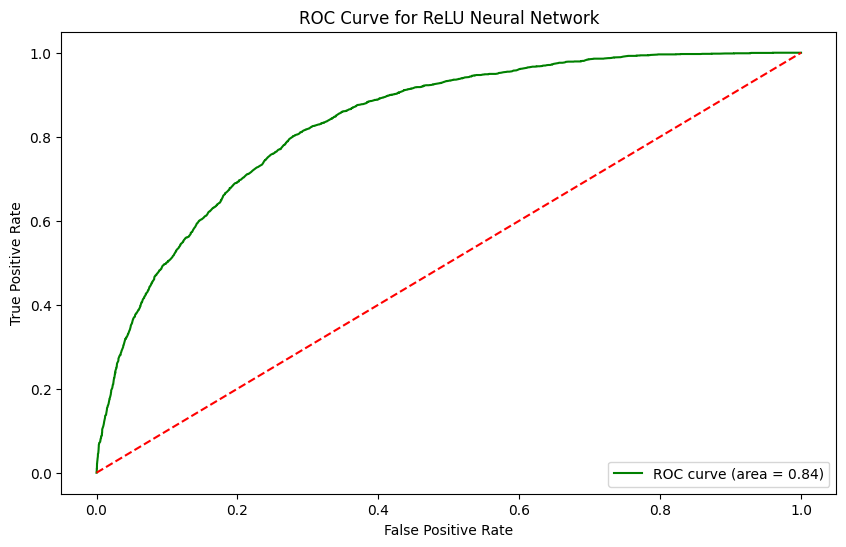

In [57]:
# ROC curve for ReLU Neural Network
y_prob_relu = relu_model.predict_proba(X_test)[:, 1]
fpr_relu, tpr_relu, thresholds_relu = roc_curve(y_test, y_prob_relu)
roc_auc_relu = auc(fpr_relu, tpr_relu)
plt.figure(figsize=(10,6))
plt.plot(fpr_relu, tpr_relu, color='green', label=f'ROC curve (area = {roc_auc_relu:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle ='--')
plt.title('ROC Curve for ReLU Neural Network')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()